In [1]:
! pip install pandas numpy missingno seaborn scikit-learn
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
filePath = 'combined.csv'
df = pd.read_csv(filePath)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,IWA,WHH,WHD,WHA,Time,Attendance,HHW,AHW,HO,AO
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,8.50,1.28,4.50,8.00,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,2.60,2.60,3.10,2.40,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,4.30,1.57,3.30,5.50,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,4.30,1.72,3.20,4.33,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,2.60,2.20,3.10,2.87,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,7.25,1.36,4.20,6.50,16:30,NaN,NaN,NaN,NaN,NaN
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,2.45,2.60,3.50,2.20,16:30,NaN,NaN,NaN,NaN,NaN
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,3.60,1.85,3.60,3.30,16:30,NaN,NaN,NaN,NaN,NaN
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,5.75,1.44,4.20,5.50,16:30,NaN,NaN,NaN,NaN,NaN


In [3]:
columnsToDrop = ['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO']
df = df.drop(columns=columnsToDrop)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,1.0,2.0,0.0,0.0,1.30,4.40,8.50,1.28,4.50,8.00
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,0.0,1.0,0.0,0.0,2.50,3.10,2.60,2.60,3.10,2.40
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,2.0,2.0,0.0,0.0,1.70,3.40,4.30,1.57,3.30,5.50
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,1.0,2.0,0.0,0.0,1.70,3.40,4.30,1.72,3.20,4.33
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,2.0,1.0,0.0,2.0,2.50,3.10,2.60,2.20,3.10,2.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,1.0,3.0,0.0,0.0,1.45,4.60,7.25,1.36,4.20,6.50
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,3.0,0.0,0.0,0.0,2.65,3.80,2.45,2.60,3.50,2.20
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,1.0,1.0,0.0,0.0,1.95,3.85,3.60,1.85,3.60,3.30
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,1.0,2.0,0.0,0.0,1.53,4.50,5.75,1.44,4.20,5.50


In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values(by='Date')
df

/var/folders/hh/pmnpfh4502s2v05fp58g729w0000gn/T/ipykernel_94362/870453394.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
9429,E0,1993-08-14,Arsenal,Coventry,0.0,3.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9438,E0,1993-08-14,West Ham,Wimbledon,0.0,2.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9437,E0,1993-08-14,Southampton,Everton,0.0,2.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9436,E0,1993-08-14,Sheffield United,Swindon,3.0,1.0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9435,E0,1993-08-14,Oldham,Ipswich,0.0,3.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3417,NaN,2025-05-25,Southampton,Arsenal,1.0,2.0,A,0.0,1.0,A,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3418,NaN,2025-05-25,Tottenham,Brighton,1.0,4.0,A,1.0,0.0,H,...,3.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3419,NaN,2025-05-25,Wolves,Brentford,1.0,1.0,D,0.0,1.0,A,...,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3410,NaN,2025-05-25,Bournemouth,Leicester,2.0,0.0,H,0.0,0.0,D,...,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
start_date = pd.Timestamp('2000-08-18')
df = df[df['Date'] >= start_date]

In [6]:
df = df.reset_index(drop=True)
df[['Date', 'HomeTeam', 'AwayTeam']].head()

,Date,HomeTeam,AwayTeam
0,2000-08-19,Sunderland,Arsenal
1,2000-08-19,Charlton,Man City
2,2000-08-19,Chelsea,West Ham
3,2000-08-19,Coventry,Middlesbrough
4,2000-08-19,Derby,Southampton


In [7]:
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
0,E0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,...,3.0,1.0,0.0,1.0,2.9,2.9,2.1,3.75,3.0,1.90
1,E0,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,...,1.0,2.0,0.0,0.0,2.2,2.9,2.7,2.10,3.2,3.10
2,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,...,1.0,2.0,0.0,0.0,1.6,3.2,4.2,1.44,3.6,6.50
3,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,...,5.0,3.0,1.0,0.0,2.2,2.9,2.7,2.30,3.2,2.62
4,E0,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,...,1.0,1.0,0.0,0.0,1.8,3.0,3.5,2.00,3.2,3.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,NaN,2025-05-25,Southampton,Arsenal,1.0,2.0,A,0.0,1.0,A,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9406,NaN,2025-05-25,Tottenham,Brighton,1.0,4.0,A,1.0,0.0,H,...,3.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9407,NaN,2025-05-25,Wolves,Brentford,1.0,1.0,D,0.0,1.0,A,...,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9408,NaN,2025-05-25,Bournemouth,Leicester,2.0,0.0,H,0.0,0.0,D,...,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek
0,E0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,...,1.0,2.9,2.9,2.1,3.75,3.0,1.90,2000,8,5
1,E0,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,...,0.0,2.2,2.9,2.7,2.10,3.2,3.10,2000,8,5
2,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,...,0.0,1.6,3.2,4.2,1.44,3.6,6.50,2000,8,5
3,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,...,0.0,2.2,2.9,2.7,2.30,3.2,2.62,2000,8,5
4,E0,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,...,0.0,1.8,3.0,3.5,2.00,3.2,3.20,2000,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,NaN,2025-05-25,Southampton,Arsenal,1.0,2.0,A,0.0,1.0,A,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6
9406,NaN,2025-05-25,Tottenham,Brighton,1.0,4.0,A,1.0,0.0,H,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6
9407,NaN,2025-05-25,Wolves,Brentford,1.0,1.0,D,0.0,1.0,A,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6
9408,NaN,2025-05-25,Bournemouth,Leicester,2.0,0.0,H,0.0,0.0,D,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6


In [9]:
odds_columns = ['IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA']
score_columns = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']

for col in odds_columns + score_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
df = df.drop_duplicates()

In [11]:
print(df.isna().sum())
print(df.info())

Div          380
Date           0
HomeTeam       0
AwayTeam       0
FTHG           0
FTAG           0
FTR            0
HTHG           0
HTAG           0
HTR            0
Referee        0
HS             0
AS             0
HST            0
AST            0
HC             0
AC             0
HF             0
AF             0
HY             0
AY             0
HR             0
AR             0
IWH          578
IWD          578
IWA          578
WHH          205
WHD          205
WHA          205
Year           0
Month          0
DayOfWeek      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9410 entries, 0 to 9409
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Div        9030 non-null   object        
 1   Date       9410 non-null   datetime64[ns]
 2   HomeTeam   9410 non-null   object        
 3   AwayTeam   9410 non-null   object        
 4   FTHG       9410 non-null   float64       
 5   FT

In [12]:
odds_columns = ['IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA']
df = df.dropna(subset=odds_columns)

In [13]:
df = df.drop(columns=['Div'])

In [14]:
df = df.drop_duplicates()

In [15]:
df = df.reset_index(drop=True)

In [16]:
print(df.isna().sum())
print(df.head())

Date         0
HomeTeam     0
AwayTeam     0
FTHG         0
FTAG         0
FTR          0
HTHG         0
HTAG         0
HTR          0
Referee      0
HS           0
AS           0
HST          0
AST          0
HC           0
AC           0
HF           0
AF           0
HY           0
AY           0
HR           0
AR           0
IWH          0
IWD          0
IWA          0
WHH          0
WHD          0
WHA          0
Year         0
Month        0
DayOfWeek    0
dtype: int64
        Date    HomeTeam       AwayTeam  FTHG  FTAG FTR  HTHG  HTAG HTR  \
0 2000-08-19  Sunderland        Arsenal   1.0   0.0   H   0.0   0.0   D   
1 2000-08-19    Charlton       Man City   4.0   0.0   H   2.0   0.0   H   
2 2000-08-19     Chelsea       West Ham   4.0   2.0   H   1.0   0.0   H   
3 2000-08-19    Coventry  Middlesbrough   1.0   3.0   A   1.0   1.0   D   
4 2000-08-19       Derby    Southampton   2.0   2.0   D   1.0   2.0   A   

         Referee  ...   AR  IWH  IWD  IWA   WHH  WHD   WHA  Year  Month

In [17]:
df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek
0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,Steve Dunn,...,1.0,2.90,2.9,2.10,3.75,3.0,1.90,2000,8,5
1,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,Rob Harris,...,0.0,2.20,2.9,2.70,2.10,3.2,3.10,2000,8,5
2,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,Graham Barber,...,0.0,1.60,3.2,4.20,1.44,3.6,6.50,2000,8,5
3,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,Barry Knight,...,0.0,2.20,2.9,2.70,2.30,3.2,2.62,2000,8,5
4,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,...,0.0,1.80,3.0,3.50,2.00,3.2,3.20,2000,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,Man City,Sheffield United,2.0,0.0,H,1.0,0.0,H,D Coote,...,0.0,1.08,11.0,26.00,1.04,12.0,29.00,2023,12,5
8714,2023-12-31,Fulham,Arsenal,2.0,1.0,H,1.0,1.0,D,J Smith,...,0.0,5.50,4.3,1.57,5.50,4.2,1.53,2023,12,6
8715,2023-12-31,Tottenham,Bournemouth,3.0,1.0,H,1.0,0.0,H,S Hooper,...,0.0,1.80,4.3,3.90,1.70,4.2,4.00,2023,12,6
8716,2024-01-01,Liverpool,Newcastle,4.0,2.0,H,0.0,0.0,D,A Taylor,...,0.0,1.47,4.9,6.00,1.40,4.8,6.50,2024,1,0


In [18]:
df = df.copy()
df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['GoalsOver2_5'] = (df['TotalGoals'] >= 2.5).astype(int)
df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5
0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,Steve Dunn,...,2.9,2.10,3.75,3.0,1.90,2000,8,5,1.0,0
1,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,Rob Harris,...,2.9,2.70,2.10,3.2,3.10,2000,8,5,4.0,1
2,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,Graham Barber,...,3.2,4.20,1.44,3.6,6.50,2000,8,5,6.0,1
3,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,Barry Knight,...,2.9,2.70,2.30,3.2,2.62,2000,8,5,4.0,1
4,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,...,3.0,3.50,2.00,3.2,3.20,2000,8,5,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,Man City,Sheffield United,2.0,0.0,H,1.0,0.0,H,D Coote,...,11.0,26.00,1.04,12.0,29.00,2023,12,5,2.0,0
8714,2023-12-31,Fulham,Arsenal,2.0,1.0,H,1.0,1.0,D,J Smith,...,4.3,1.57,5.50,4.2,1.53,2023,12,6,3.0,1
8715,2023-12-31,Tottenham,Bournemouth,3.0,1.0,H,1.0,0.0,H,S Hooper,...,4.3,3.90,1.70,4.2,4.00,2023,12,6,4.0,1
8716,2024-01-01,Liverpool,Newcastle,4.0,2.0,H,0.0,0.0,D,A Taylor,...,4.9,6.00,1.40,4.8,6.50,2024,1,0,6.0,1


In [19]:
df.dtypes

Date            datetime64[ns]
HomeTeam                object
AwayTeam                object
FTHG                   float64
FTAG                   float64
FTR                     object
HTHG                   float64
HTAG                   float64
HTR                     object
Referee                 object
HS                     float64
AS                     float64
HST                    float64
AST                    float64
HC                     float64
AC                     float64
HF                     float64
AF                     float64
HY                     float64
AY                     float64
HR                     float64
AR                     float64
IWH                    float64
IWD                    float64
IWA                    float64
WHH                    float64
WHD                    float64
WHA                    float64
Year                     int32
Month                    int32
DayOfWeek                int32
TotalGoals             float64
GoalsOve

In [20]:
df['HomeTeam_mean_FTHG'] = df['HomeTeam'].map(df.groupby('HomeTeam')['FTHG'].mean())
df['AwayTeam_mean_FTAG'] = df['AwayTeam'].map(df.groupby('AwayTeam')['FTAG'].mean())

df = pd.get_dummies(df, columns=['HomeTeam', 'AwayTeam', 'FTR', 'HTR'])

In [21]:
df

,Date,FTHG,FTAG,HTHG,HTAG,Referee,HS,AS,HST,AST,...,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,FTR_A,FTR_D,FTR_H,HTR_A,HTR_D,HTR_H
0,2000-08-19,1.0,0.0,0.0,0.0,Steve Dunn,8.0,14.0,2.0,7.0,...,False,False,False,False,False,False,True,False,True,False
1,2000-08-19,4.0,0.0,2.0,0.0,Rob Harris,17.0,8.0,14.0,4.0,...,False,False,False,False,False,False,True,False,False,True
2,2000-08-19,4.0,2.0,1.0,0.0,Graham Barber,17.0,12.0,10.0,5.0,...,False,True,False,False,False,False,True,False,False,True
3,2000-08-19,1.0,3.0,1.0,1.0,Barry Knight,6.0,16.0,3.0,9.0,...,False,False,False,False,True,False,False,False,True,False
4,2000-08-19,2.0,2.0,1.0,2.0,Andy D'Urso,6.0,13.0,4.0,6.0,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,2.0,0.0,1.0,0.0,D Coote,18.0,4.0,4.0,2.0,...,False,False,False,False,False,False,True,False,False,True
8714,2023-12-31,2.0,1.0,1.0,1.0,J Smith,15.0,13.0,4.0,3.0,...,False,False,False,False,False,False,True,False,True,False
8715,2023-12-31,3.0,1.0,1.0,0.0,S Hooper,12.0,24.0,6.0,4.0,...,False,False,False,False,False,False,True,False,False,True
8716,2024-01-01,4.0,2.0,0.0,0.0,A Taylor,34.0,5.0,15.0,3.0,...,False,False,False,False,False,False,True,False,True,False


In [22]:
boolean_columns = df.select_dtypes(include=['bool']).columns
df[boolean_columns] = df[boolean_columns].astype(int)
df

,Date,FTHG,FTAG,HTHG,HTAG,Referee,HS,AS,HST,AST,...,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,FTR_A,FTR_D,FTR_H,HTR_A,HTR_D,HTR_H
0,2000-08-19,1.0,0.0,0.0,0.0,Steve Dunn,8.0,14.0,2.0,7.0,...,0,0,0,0,0,0,1,0,1,0
1,2000-08-19,4.0,0.0,2.0,0.0,Rob Harris,17.0,8.0,14.0,4.0,...,0,0,0,0,0,0,1,0,0,1
2,2000-08-19,4.0,2.0,1.0,0.0,Graham Barber,17.0,12.0,10.0,5.0,...,0,1,0,0,0,0,1,0,0,1
3,2000-08-19,1.0,3.0,1.0,1.0,Barry Knight,6.0,16.0,3.0,9.0,...,0,0,0,0,1,0,0,0,1,0
4,2000-08-19,2.0,2.0,1.0,2.0,Andy D'Urso,6.0,13.0,4.0,6.0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,2.0,0.0,1.0,0.0,D Coote,18.0,4.0,4.0,2.0,...,0,0,0,0,0,0,1,0,0,1
8714,2023-12-31,2.0,1.0,1.0,1.0,J Smith,15.0,13.0,4.0,3.0,...,0,0,0,0,0,0,1,0,1,0
8715,2023-12-31,3.0,1.0,1.0,0.0,S Hooper,12.0,24.0,6.0,4.0,...,0,0,0,0,0,0,1,0,0,1
8716,2024-01-01,4.0,2.0,0.0,0.0,A Taylor,34.0,5.0,15.0,3.0,...,0,0,0,0,0,0,1,0,1,0


In [25]:
sns.set_style("whitegrid")

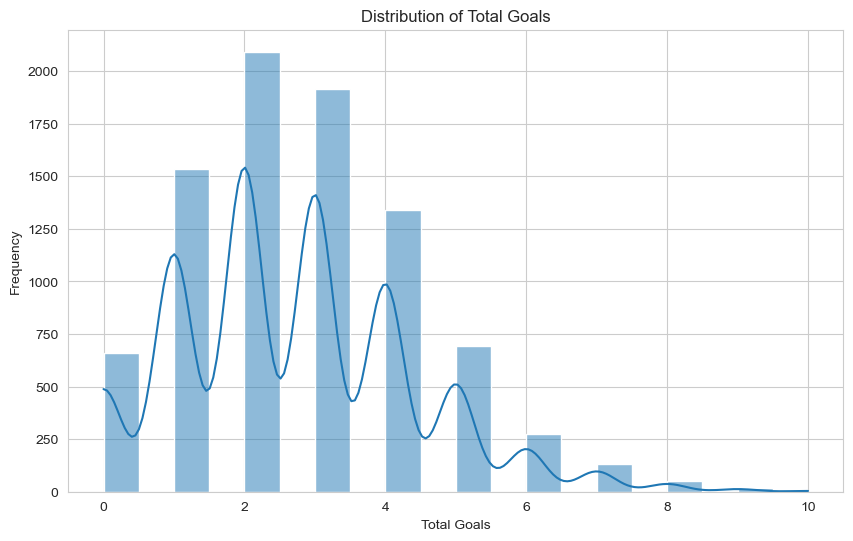

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalGoals'], bins=20, kde=True)
plt.title('Distribution of Total Goals')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.show()

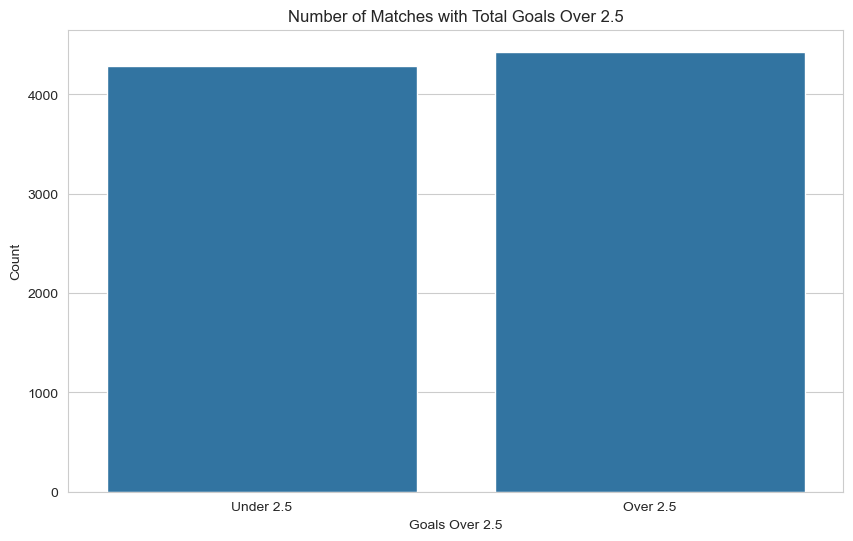

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='GoalsOver2_5', data=df)
plt.title('Number of Matches with Total Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Count')
plt.xticks([0, 1], ['Under 2.5', 'Over 2.5'])
plt.show()

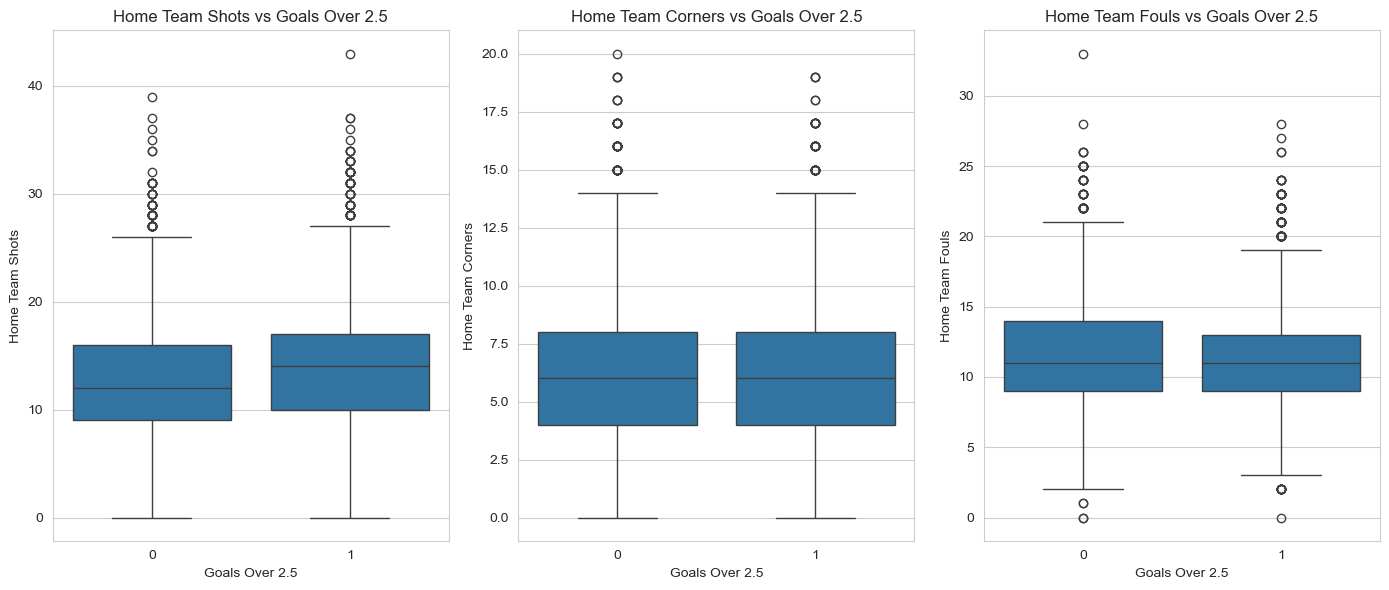

In [28]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='HS', data=df)
plt.title('Home Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Shots')

plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='HC', data=df)
plt.title('Home Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Corners')

plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='HF', data=df)
plt.title('Home Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Fouls')

plt.tight_layout()
plt.show()

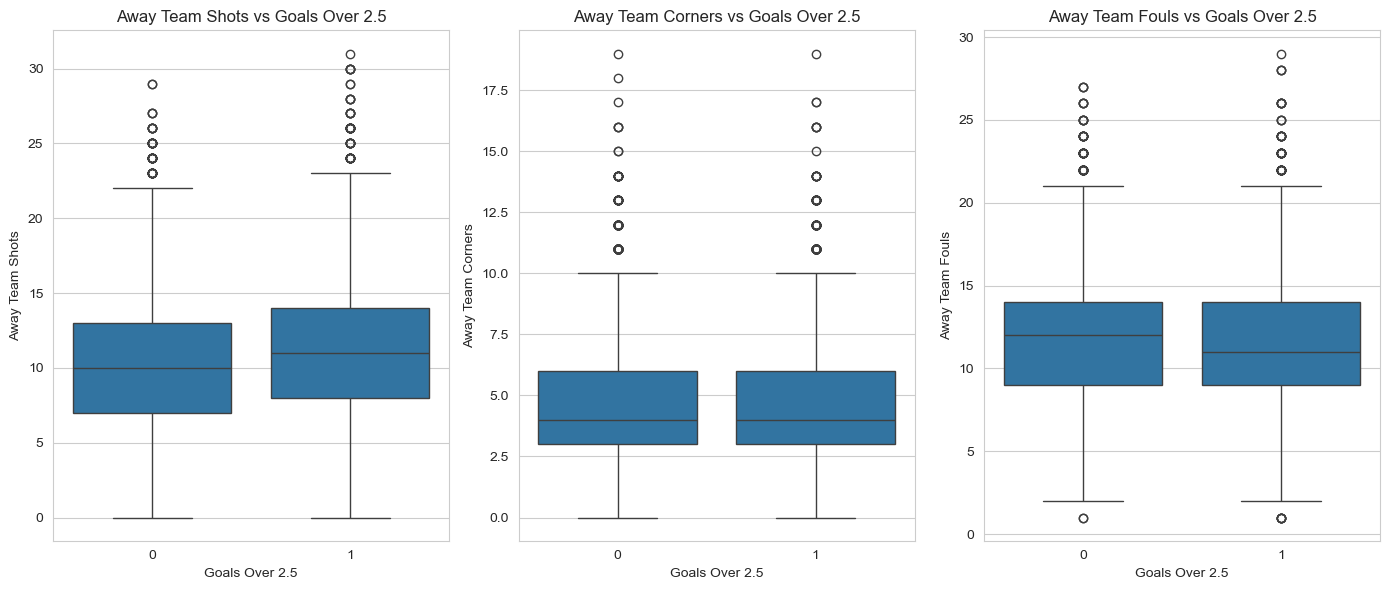

In [29]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='AS', data=df)
plt.title('Away Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Shots')

plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='AC', data=df)
plt.title('Away Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Corners')

plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='AF', data=df)
plt.title('Away Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Fouls')

plt.tight_layout()
plt.show()

In [30]:
print(df[['HomeTeam_mean_FTHG', 'AwayTeam_mean_FTAG']].head())

   HomeTeam_mean_FTHG  AwayTeam_mean_FTAG
0            1.088462            1.606407
1            1.357143            1.620525
2            2.045767            1.075916
3            0.736842            0.875000
4            0.961538            1.020270


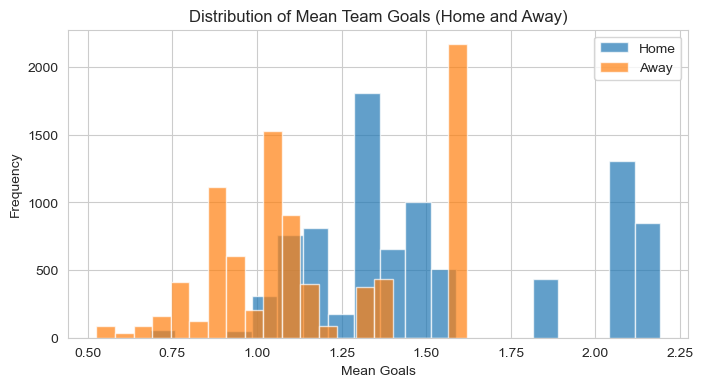

In [32]:
plt.figure(figsize=(8,4))
plt.hist(df['HomeTeam_mean_FTHG'], bins=20, alpha=0.7, label='Home')
plt.hist(df['AwayTeam_mean_FTAG'], bins=20, alpha=0.7, label='Away')
plt.xlabel('Mean Goals')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Team Goals (Home and Away)')
plt.legend()
plt.show()

In [35]:
cor_target = numeric_df.corr()['GoalsOver2_5'].sort_values(ascending=False)
print(cor_target)

GoalsOver2_5              1.000000
TotalGoals                0.803185
FTHG                      0.569300
FTAG                      0.517996
HTHG                      0.393505
                            ...   
AwayTeam_Middlesbrough   -0.031703
HF                       -0.039627
AF                       -0.041810
HTR_D                    -0.264131
FTR_D                    -0.299506
Name: GoalsOver2_5, Length: 127, dtype: float64


In [37]:
df.to_csv('cleaned_data.csv', index=False)